<a href="https://colab.research.google.com/github/Karla12-B/Challenge-Telecom-2da-Parte/blob/main/Desafio_Telecom_2da.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df_analisis = pd.read_csv('/content/drive/MyDrive/TelecomX_Tratado.csv')

Mounted at /content/drive


In [3]:
import pandas as pd

# 1. Definimos el diccionario de traducción (el mismo que usamos antes)
dicc_traduccion = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Socio',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Meses_Permanencia',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Factura_Digital',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Monto_Mensual',
    'account.Charges.Total': 'Monto_Total'
}

# 2. Aplicamos el cambio y lo guardamos en la variable df_analisis
df_analisis = df_analisis.rename(columns=dicc_traduccion)



Eliminación de Columnas Irrelevantes

In [4]:
# Columnas a eliminar
columnas_irrelevantes = [
    'customerID',
    'customer.gender',
    'phone.PhoneService',
    'account.PaperlessBilling'
]

# Eliminamos las columnas del DataFrame de análisis
# Usamos errors='ignore' para evitar errores si la celda se ejecuta dos veces
df_ml = df_analisis.drop(columns=columnas_irrelevantes, errors='ignore')

print(f"✅ Columnas eliminadas. El dataset ahora tiene {df_ml.shape[1]} columnas.")
print("Columnas restantes:", df_ml.columns.tolist())

# Visualizamos las primeras filas para confirmar
display(df_ml.head())

✅ Columnas eliminadas. El dataset ahora tiene 22 columnas.
Columnas restantes: ['ID_Cliente', 'Evasion', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias']


,ID_Cliente,Evasion,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


Encoding

In [5]:
# --- ENCODING ---

# Aplicamos One-Hot Encoding a todo el DataFrame
df_final = pd.get_dummies(df_ml, drop_first=True)

# Verificamos la transformación
print(f"✅ Encoding completado.")
print(f"Dimensiones originales: {df_ml.shape}")
print(f"Nuevas dimensiones: {df_final.shape}")
print("\nNuevas columnas generadas:")
print(df_final.columns.tolist())

# Mostramos las primeras filas para ver los 1s y 0s
display(df_final.head())

✅ Encoding completado.
Dimensiones originales: (7267, 22)
Nuevas dimensiones: (7267, 7298)

Nuevas columnas generadas:
['customer_SeniorCitizen', 'customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias', 'ID_Cliente_0003-MKNFE', 'ID_Cliente_0004-TLHLJ', 'ID_Cliente_0011-IGKFF', 'ID_Cliente_0013-EXCHZ', 'ID_Cliente_0013-MHZWF', 'ID_Cliente_0013-SMEOE', 'ID_Cliente_0014-BMAQU', 'ID_Cliente_0015-UOCOJ', 'ID_Cliente_0016-QLJIS', 'ID_Cliente_0017-DINOC', 'ID_Cliente_0017-IUDMW', 'ID_Cliente_0018-NYROU', 'ID_Cliente_0019-EFAEP', 'ID_Cliente_0019-GFNTW', 'ID_Cliente_0020-INWCK', 'ID_Cliente_0020-JDNXP', 'ID_Cliente_0021-IKXGC', 'ID_Cliente_0022-TCJCI', 'ID_Cliente_0023-HGHWL', 'ID_Cliente_0023-UYUPN', 'ID_Cliente_0023-XUOPT', 'ID_Cliente_0027-KWYKW', 'ID_Cliente_0030-FNXPP', 'ID_Cliente_0031-PVLZI', 'ID_Cliente_0032-PGELS', 'ID_Cliente_0036-IHMOT', 'ID_Cliente_0040-HALCW', 'ID_Cliente_0042-JVWOJ', 'ID_Cliente_0042-RLHYP', 'ID_Cliente_0047-ZHDTW', 'ID_Cliente_00

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,ID_Cliente_0003-MKNFE,ID_Cliente_0004-TLHLJ,ID_Cliente_0011-IGKFF,ID_Cliente_0013-EXCHZ,ID_Cliente_0013-MHZWF,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.19,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,2.00,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.46,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.27,False,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.80,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True


VERIFICACIÓN DE LA PROPORCIÓN DE CANCELACIÓN (CHURN)

In [7]:
# --- PASO: VERIFICACIÓN DE LA PROPORCIÓN DE CANCELACIÓN (CHURN) ---

# 1. Calculamos el conteo absoluto y la proporción porcentual
# Nota: Usamos 'Evasion_Yes' que es el nombre generado tras el Encoding
conteo_clases = df_final['Evasion_Yes'].value_counts()
proporcion_clases = df_final['Evasion_Yes'].value_counts(normalize=True) * 100

# 2. Mostramos los resultados detallados
print("--- Análisis de Proporción de Clientes ---")
print(f"Clientes que Permanecen (0): {conteo_clases[0]} ({proporcion_clases[0]:.2f}%)")
print(f"Clientes que Cancelaron (1):  {conteo_clases[1]} ({proporcion_clases[1]:.2f}%)")



--- Análisis de Proporción de Clientes ---
Clientes que Permanecen (0): 5398 (74.28%)
Clientes que Cancelaron (1):  1869 (25.72%)


/tmp/ipykernel_333/569869018.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Clientes que Permanecen (0): {conteo_clases[0]} ({proporcion_clases[0]:.2f}%)")
/tmp/ipykernel_333/569869018.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Clientes que Cancelaron (1):  {conteo_clases[1]} ({proporcion_clases[1]:.2f}%)")


/tmp/ipykernel_333/3438730735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proporcion_clases.index, y=proporcion_clases.values, palette='viridis')


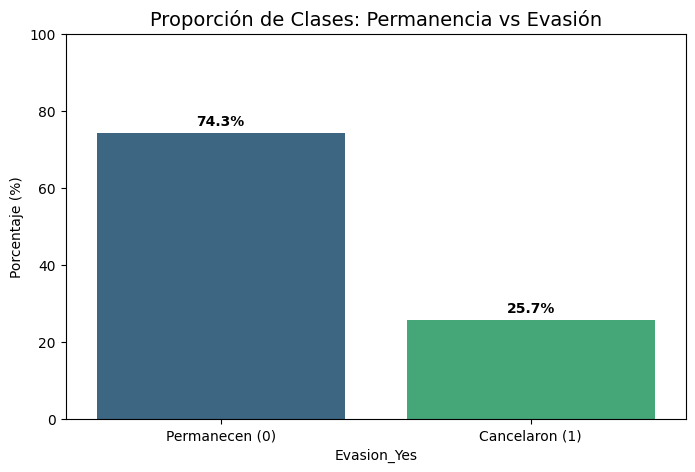

In [8]:
# 3. Visualización para evaluar el desbalance visualmente
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=proporcion_clases.index, y=proporcion_clases.values, palette='viridis')
plt.title('Proporción de Clases: Permanencia vs Evasión', fontsize=14)
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 100)

# Añadir etiquetas de porcentaje sobre las barras
for i, v in enumerate(proporcion_clases.values):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.show()

SMOTE

In [9]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Separamos la variable objetivo (Evasion_Yes) del resto de los datos
X = df_final.drop('Evasion_Yes', axis=1)
y = df_final['Evasion_Yes']

# 2. Inicializamos SMOTE
# random_state=42 asegura que los resultados sean reproducibles
smote = SMOTE(random_state=42)

# 3. Aplicamos el balanceo (solo se generan datos sintéticos para el entrenamiento)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 4. Verificamos el nuevo balanceo
print("--- Proporción después de aplicar SMOTE ---")
print(y_resampled.value_counts(normalize=True) * 100)

print(f"\nDimensiones originales: {X.shape}")
print(f"Nuevas dimensiones:     {X_resampled.shape}")

--- Proporción después de aplicar SMOTE ---
Evasion_Yes
False    50.0
True     50.0
Name: proportion, dtype: float64

Dimensiones originales: (7267, 7297)
Nuevas dimensiones:     (10796, 7297)
